In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions_glitterin"

/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Make a function to save the information to the df

In [3]:
def make_fit_summary_row(fit_name, sf_results, nk):
    return {
        "Fit Case": fit_name,
        "nk": nk,
        "Scale Factor": sf_results["best_sf"],
#         "Best amax (cm)": sf_results["best_rvol_max_cm"],
        "Best amax (micron)": sf_results["best_rvol_max_micron"],
        "chi squared": sf_results["chi_sq"],
        "Best Index": sf_results["best_idx_arr"],
    }

rows_DSHARP = []
rows_DSHARP_w_eff = []

# Set variables and run glitterin

In [4]:
# Constants
BandsIndex = ["Band 4 nterms2",  "Band 5 robust -1", "Band 6", "Band 7 nterms2"]
bands_naming = ['Band4_nterms2', "Band5_robust_minus1", 'Band6', 'Band7_nterms2']
bands_labels = ['Band 4',          "Band 5",      'Band 6', 'Band 7']
# BandLabelsForPlots = ['Band 4', 'Band 5', 'Band 6', 'Band 7']

num_bands = len(BandsIndex)
 
lambda_bands_cm = {
    b: mm_to_cm(lambda_mm[b]) 
    for b in BandsIndex
}

# ms = {alma_band_ms[b]
#     for b in BandsIndex
# }

# ms


# band_colors = [alma_band_colors[b] for b in BandsIndex]

In [5]:
lambda_bands_cm['Band 4 nterms2'] = 0.207
lambda_bands_cm['Band 5 robust -1'] = 0.148
lambda_bands_cm['Band 6'] = 0.129
lambda_bands_cm['Band 7 nterms2'] = 0.087

In [6]:
lambda_bands_cm

{'Band 4 nterms2': 0.207,
 'Band 5 robust -1': 0.148,
 'Band 6': 0.129,
 'Band 7 nterms2': 0.087}

In [7]:
# # Load in POLF
# df_POLF = load_POLF(BandsIndex, print_things = True)


# df_POLF

In [8]:
# Load in POLF
df_POLF = load_POLF(BandsIndex, print_things = True, bias = 'debiased')


df_POLF

Band = Band 4 nterms2
Band = Band 5 robust -1
Band = Band 6
Band = Band 7 nterms2
 in load_POLF, results = {'Band': ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2'], 'POLF_Gaussian': [np.float64(1.1638928), np.float64(1.3484494), np.float64(1.41269695), np.float64(0.8981155)], 'POLF_maxPOLI': [np.float64(1.5608873), np.float64(1.5119315), np.float64(1.4862873), np.float64(1.0840478)], 'POLF_err_maxPOLI': [np.float64(0.039390835391389996), np.float64(0.07498792265646001), np.float64(0.030210346000000003), np.float64(0.01504517435846)], 'POLF_maxStokesI': [np.float64(1.3672079), np.float64(1.4014986999999999), np.float64(1.4639224), np.float64(1.0420333)], 'POLF_err_maxStokesI': [np.float64(0.03691720986757), np.float64(0.07397171203147), np.float64(0.029772913), np.float64(0.01493462948155)]}


,Band,POLF_Gaussian,POLF_maxPOLI,POLF_err_maxPOLI,POLF_maxStokesI,POLF_err_maxStokesI,POLF_mean
0,Band 4 nterms2,1.163893,1.560887,0.039391,1.367208,0.036917,0.833659
1,Band 5 robust -1,1.348449,1.511931,0.074988,1.401499,0.073972,0.882168
2,Band 6,1.412697,1.486287,0.030210,1.463922,0.029773,0.884578
3,Band 7 nterms2,0.898115,1.084048,0.015045,1.042033,0.014935,0.610835


In [9]:
amin = 2e-4 # 0.1 micron lower boundary
amax = 0.5 # maximum 5000 micron
na = 2000



max_rvol_grid_cm = np.geomspace(amin, amax, na)
#np.logspace(-3, 0, 1000) 


# Original logarithmic grid
# a_grid_cm = np.geomspace(amin, amax, na)


xmin = 30#1e-3 + 20
xmax = 1e3 + 20

In [10]:
# Choose the array of a_max values we are looking at 
# Figure 12 in in 2025 has 1e-3 to 1e0 cm # This corresponds to 10 to 10000 micron 
#max_rvol_grid_cm = np.logspace(-3, 0, 1000) 



nk_data = np.genfromtxt(
    "nk_values.txt",
    dtype=None,
    names=True,
    encoding=None
)

data_n = {}
data_k = {}

for b, b_file in zip(BandsIndex, bands_naming):
    row = nk_data[nk_data["band"] == b_file][0]
    
    data_n[b] = float(row["n"])
    data_k[b] = float(row["k"])

In [11]:
# results = RunGlitterinPowerLawDistAveraged(BandsIndex, lambda_bands_cm, data_n, data_k, max_rvol_grid_cm)

# np.savez("results_glitterin_fixed_lambda_SAME_BOUNDS_omega_eff.npz", results=results)

In [12]:
# data = np.load("results_glitterin.npz", allow_pickle=True)

data = np.load("results_glitterin_fixed_lambda_SAME_BOUNDS_omega_eff.npz", allow_pickle=True)
results = data["results"].item()

In [13]:
# raise SystemExit("Stop here")

# P$\omega$ vs maximum grain size, with scale factor

In [14]:
POLF_index = 'max Stokes I'

In [15]:
albedo = 'w'

BandsInFit_all = ["Band 4 nterms2",  "Band 5 robust -1", "Band 6", "Band 7 nterms2"]
sf_results_all = find_sf_glitterin(results, BandsIndex, BandsInFit_all, df_POLF, POLF_index, 
                                   albedo = albedo, 
                                   print_results = False)
rows_DSHARP.append(
    make_fit_summary_row(
        fit_name = "All",
        sf_results = sf_results_all,
        nk = 'DSHARP',
    )
)


BandsInFit_wo5 = ["Band 4 nterms2", "Band 6", "Band 7 nterms2"]
sf_results_wo5 = find_sf_glitterin(results, BandsIndex, BandsInFit_wo5, df_POLF, POLF_index,
                                   albedo = albedo, 
                                   print_results = False)
rows_DSHARP.append(
    make_fit_summary_row(
        fit_name = "No 5",
        sf_results = sf_results_wo5,
        nk = 'DSHARP',
    )
)
                  
                  
BandsInFit_wo6 = ["Band 4 nterms2", "Band 5 robust -1",  "Band 7 nterms2"]
sf_results_wo6 = find_sf_glitterin(results, BandsIndex, BandsInFit_wo6, df_POLF, POLF_index,
                                   albedo = albedo, 
                                   print_results = False)
rows_DSHARP.append(
    make_fit_summary_row(
        fit_name = "No 6",
        sf_results = sf_results_wo6,
        nk = 'DSHARP',
    )
)
                  
                  
BandsInFit_just47 = ["Band 4 nterms2",  "Band 7 nterms2"]
sf_results_just47 = find_sf_glitterin(results, BandsIndex, BandsInFit_just47, df_POLF, POLF_index,
                                      albedo = albedo, 
                                     trouble = True, trouble_index = 2, choose_trouble_index = True)
rows_DSHARP.append(
    make_fit_summary_row(
        fit_name = "47",
        sf_results = sf_results_just47,
        nk = 'DSHARP',
    )
)

# Bands in fit
bands_included_in_fit = [BandsInFit_all, BandsInFit_wo5, BandsInFit_wo6, BandsInFit_just47]

# x-axis values
results_array = [sf_results_all, sf_results_wo5, sf_results_wo6, sf_results_just47]

The POLF value we are considering is: max Stokes I

 The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']

 All rvol_max_cm are the same: True
The POLF value we are considering is: max Stokes I

 The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 6', 'Band 7 nterms2']

 All rvol_max_cm are the same: True
The POLF value we are considering is: max Stokes I

 The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 7 nterms2']

 All rvol_max_cm are the same: True
The POLF value we are considering is: max Stokes I

 The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
T

$P * \omega_{\text{eff}}$

In [16]:
albedo = 'w_eff'

BandsInFit_all = ["Band 4 nterms2",  "Band 5 robust -1", "Band 6", "Band 7 nterms2"]
sf_results_all = find_sf_glitterin(results, BandsIndex, BandsInFit_all, df_POLF, POLF_index, 
                                   albedo = albedo, 
                                   print_results = False)
rows_DSHARP_w_eff.append(
    make_fit_summary_row(
        fit_name = "All",
        sf_results = sf_results_all,
        nk = 'DSHARP',
    )
)


BandsInFit_wo5 = ["Band 4 nterms2", "Band 6", "Band 7 nterms2"]
sf_results_wo5 = find_sf_glitterin(results, BandsIndex, BandsInFit_wo5, df_POLF, POLF_index,
                                   albedo = albedo, 
                                   print_results = False)
rows_DSHARP_w_eff.append(
    make_fit_summary_row(
        fit_name = "No 5",
        sf_results = sf_results_wo5,
        nk = 'DSHARP',
    )
)
                  
                  
BandsInFit_wo6 = ["Band 4 nterms2", "Band 5 robust -1",  "Band 7 nterms2"]
sf_results_wo6 = find_sf_glitterin(results, BandsIndex, BandsInFit_wo6, df_POLF, POLF_index,
                                   albedo = albedo, 
                                   print_results = False)
rows_DSHARP_w_eff.append(
    make_fit_summary_row(
        fit_name = "No 6",
        sf_results = sf_results_wo6,
        nk = 'DSHARP',
    )
)
                  
                  
BandsInFit_just47 = ["Band 4 nterms2",  "Band 7 nterms2"]
sf_results_just47 = find_sf_glitterin(results, BandsIndex, BandsInFit_just47, df_POLF, POLF_index,
                                      albedo = albedo, 
                                     trouble = True, trouble_index = 2, choose_trouble_index = True)
rows_DSHARP_w_eff.append(
    make_fit_summary_row(
        fit_name = "47",
        sf_results = sf_results_just47,
        nk = 'DSHARP',
    )
)


# x-axis values
results_array_w_eff = [sf_results_all, sf_results_wo5, sf_results_wo6, sf_results_just47]

The POLF value we are considering is: max Stokes I

 The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']

 All rvol_max_cm are the same: True
The POLF value we are considering is: max Stokes I

 The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 6', 'Band 7 nterms2']

 All rvol_max_cm are the same: True
The POLF value we are considering is: max Stokes I

 The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
The Bands included in the fit are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 7 nterms2']

 All rvol_max_cm are the same: True
The POLF value we are considering is: max Stokes I

 The Bands we are looking at are: ['Band 4 nterms2', 'Band 5 robust -1', 'Band 6', 'Band 7 nterms2']
T

In [17]:
df_DSHARP = pd.DataFrame(rows_DSHARP)

df_DSHARP.style.format({
    'Scale Factor': '{:.2f}',
    'Best amax (micron)': '{:.0f}',
    'chi squared': '{:.2f}'
})


,Fit Case,nk,Scale Factor,Best amax (micron),chi squared,Best Index
0,All,DSHARP,1.77,212,4.66,1192
1,No 5,DSHARP,1.81,214,6.25,1194
2,No 6,DSHARP,1.79,212,4.51,1192
3,47,DSHARP,1.83,215,8.46,1195


In [18]:
df_DSHARP_w_eff = pd.DataFrame(rows_DSHARP_w_eff)

df_DSHARP_w_eff.style.format({
    'Scale Factor': '{:.2f}',
    'Best amax (micron)': '{:.0f}',
    'chi squared': '{:.2f}'
})

,Fit Case,nk,Scale Factor,Best amax (micron),chi squared,Best Index
0,All,DSHARP,1.83,209,4.54,1188
1,No 5,DSHARP,1.88,211,5.93,1190
2,No 6,DSHARP,1.85,209,4.39,1188
3,47,DSHARP,1.90,212,8.71,1192


# Scale Factor Plots

i = 0 and P_times_omega[:, j] * sf max is 1.5364357922168332
i = 0 and P_times_omega[:, j] * sf max is 1.5150424119440364
i = 0 and P_times_omega[:, j] * sf max is 1.4803427722752613
i = 0 and P_times_omega[:, j] * sf max is 1.4264948141163416
i = 1 and P_times_omega[:, j] * sf max is 1.573609945749528
i = 1 and P_times_omega[:, j] * sf max is 1.551698951394273
i = 1 and P_times_omega[:, j] * sf max is 1.516159751921495
i = 1 and P_times_omega[:, j] * sf max is 1.461008939276783
i = 2 and P_times_omega[:, j] * sf max is 1.5534102782952628
i = 2 and P_times_omega[:, j] * sf max is 1.5317805447446715
i = 2 and P_times_omega[:, j] * sf max is 1.4966975447340793
i = 2 and P_times_omega[:, j] * sf max is 1.4422546763154855
i = 3 and P_times_omega[:, j] * sf max is 1.5870676156041805
i = 3 and P_times_omega[:, j] * sf max is 1.5649692362307914
i = 3 and P_times_omega[:, j] * sf max is 1.5291261019648361
i = 3 and P_times_omega[:, j] * sf max is 1.4735036340469778


Text(0.85, 0.88, '$\\star$')

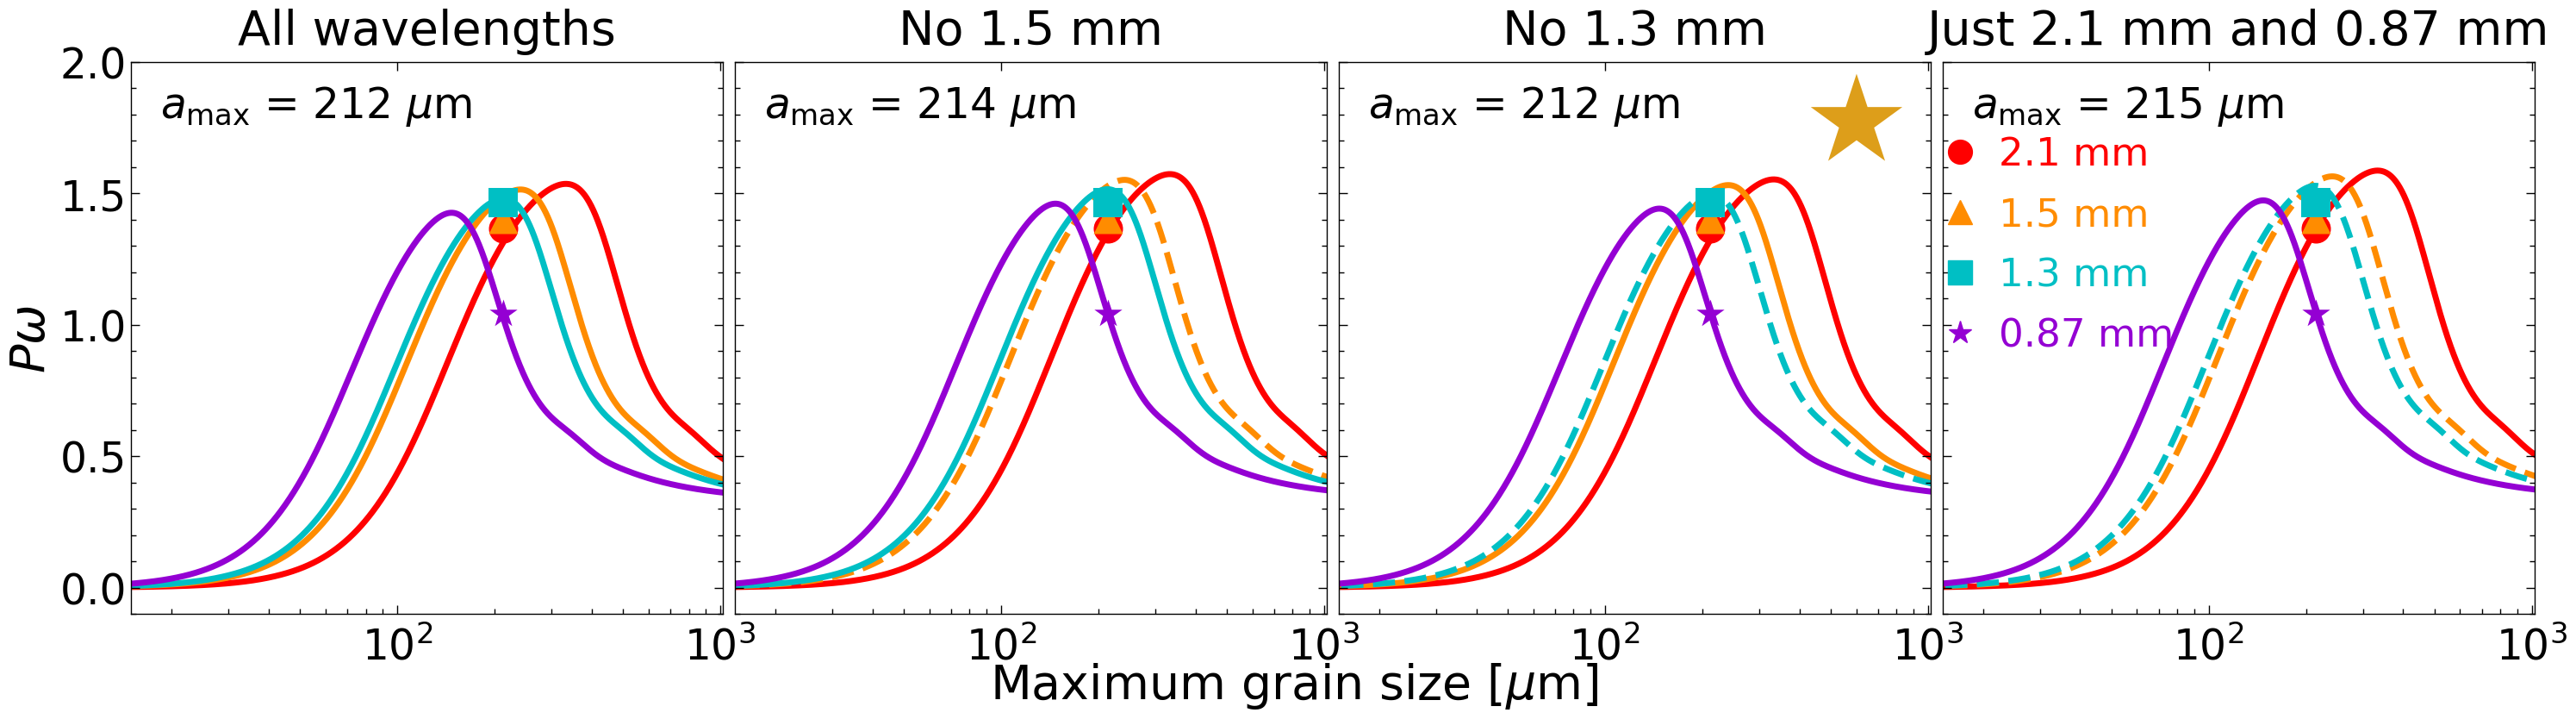

In [19]:


fig, ax = scale_factor_plot_for_writeup_glitterin(BandsIndex,                  
                                        bands_labels, 
                                        results_array,
                                        bands_included_in_fit,             
                                        df_POLF,    
                                        plot_sf = False,
                                        plot_chi_sq = False, 
                                        BandLegend_bbox_to_anchor=(0.45, 0.93),
                                        xmin = 15,
                                                  legend_loc = 3
                                        )


ax[2].text(
    0.85, 0.88,
    r'$\star$',
    transform=ax[2].transAxes,
    fontsize=200,
    color= '#dd9e1aff',
    ha='center',
    va='center'
)


# plt.savefig(writeup_image_folder_path + '/glitterin/' + "DustModelPlot_GlitterinGrid_omega_eff.pdf", 
#             dpi=300, 
#             bbox_inches='tight')

In [20]:
results_array_3 = [results_array[0], results_array[1], results_array[3]]
results_array_w_eff_3 = [results_array_w_eff[0], results_array_w_eff[1], results_array_w_eff[3]]
bands_included_in_fit_3 = [bands_included_in_fit[0], bands_included_in_fit[1], bands_included_in_fit[3]]

i = 0 and P_times_omega[:, j] * sf max is 1.5364357922168332
i = 0 and P_times_omega[:, j] * sf max is 1.5150424119440364
i = 0 and P_times_omega[:, j] * sf max is 1.4803427722752613
i = 0 and P_times_omega[:, j] * sf max is 1.4264948141163416
i = 1 and P_times_omega[:, j] * sf max is 1.573609945749528
i = 1 and P_times_omega[:, j] * sf max is 1.551698951394273
i = 1 and P_times_omega[:, j] * sf max is 1.516159751921495
i = 1 and P_times_omega[:, j] * sf max is 1.461008939276783
i = 2 and P_times_omega[:, j] * sf max is 1.5870676156041805
i = 2 and P_times_omega[:, j] * sf max is 1.5649692362307914
i = 2 and P_times_omega[:, j] * sf max is 1.5291261019648361
i = 2 and P_times_omega[:, j] * sf max is 1.4735036340469778


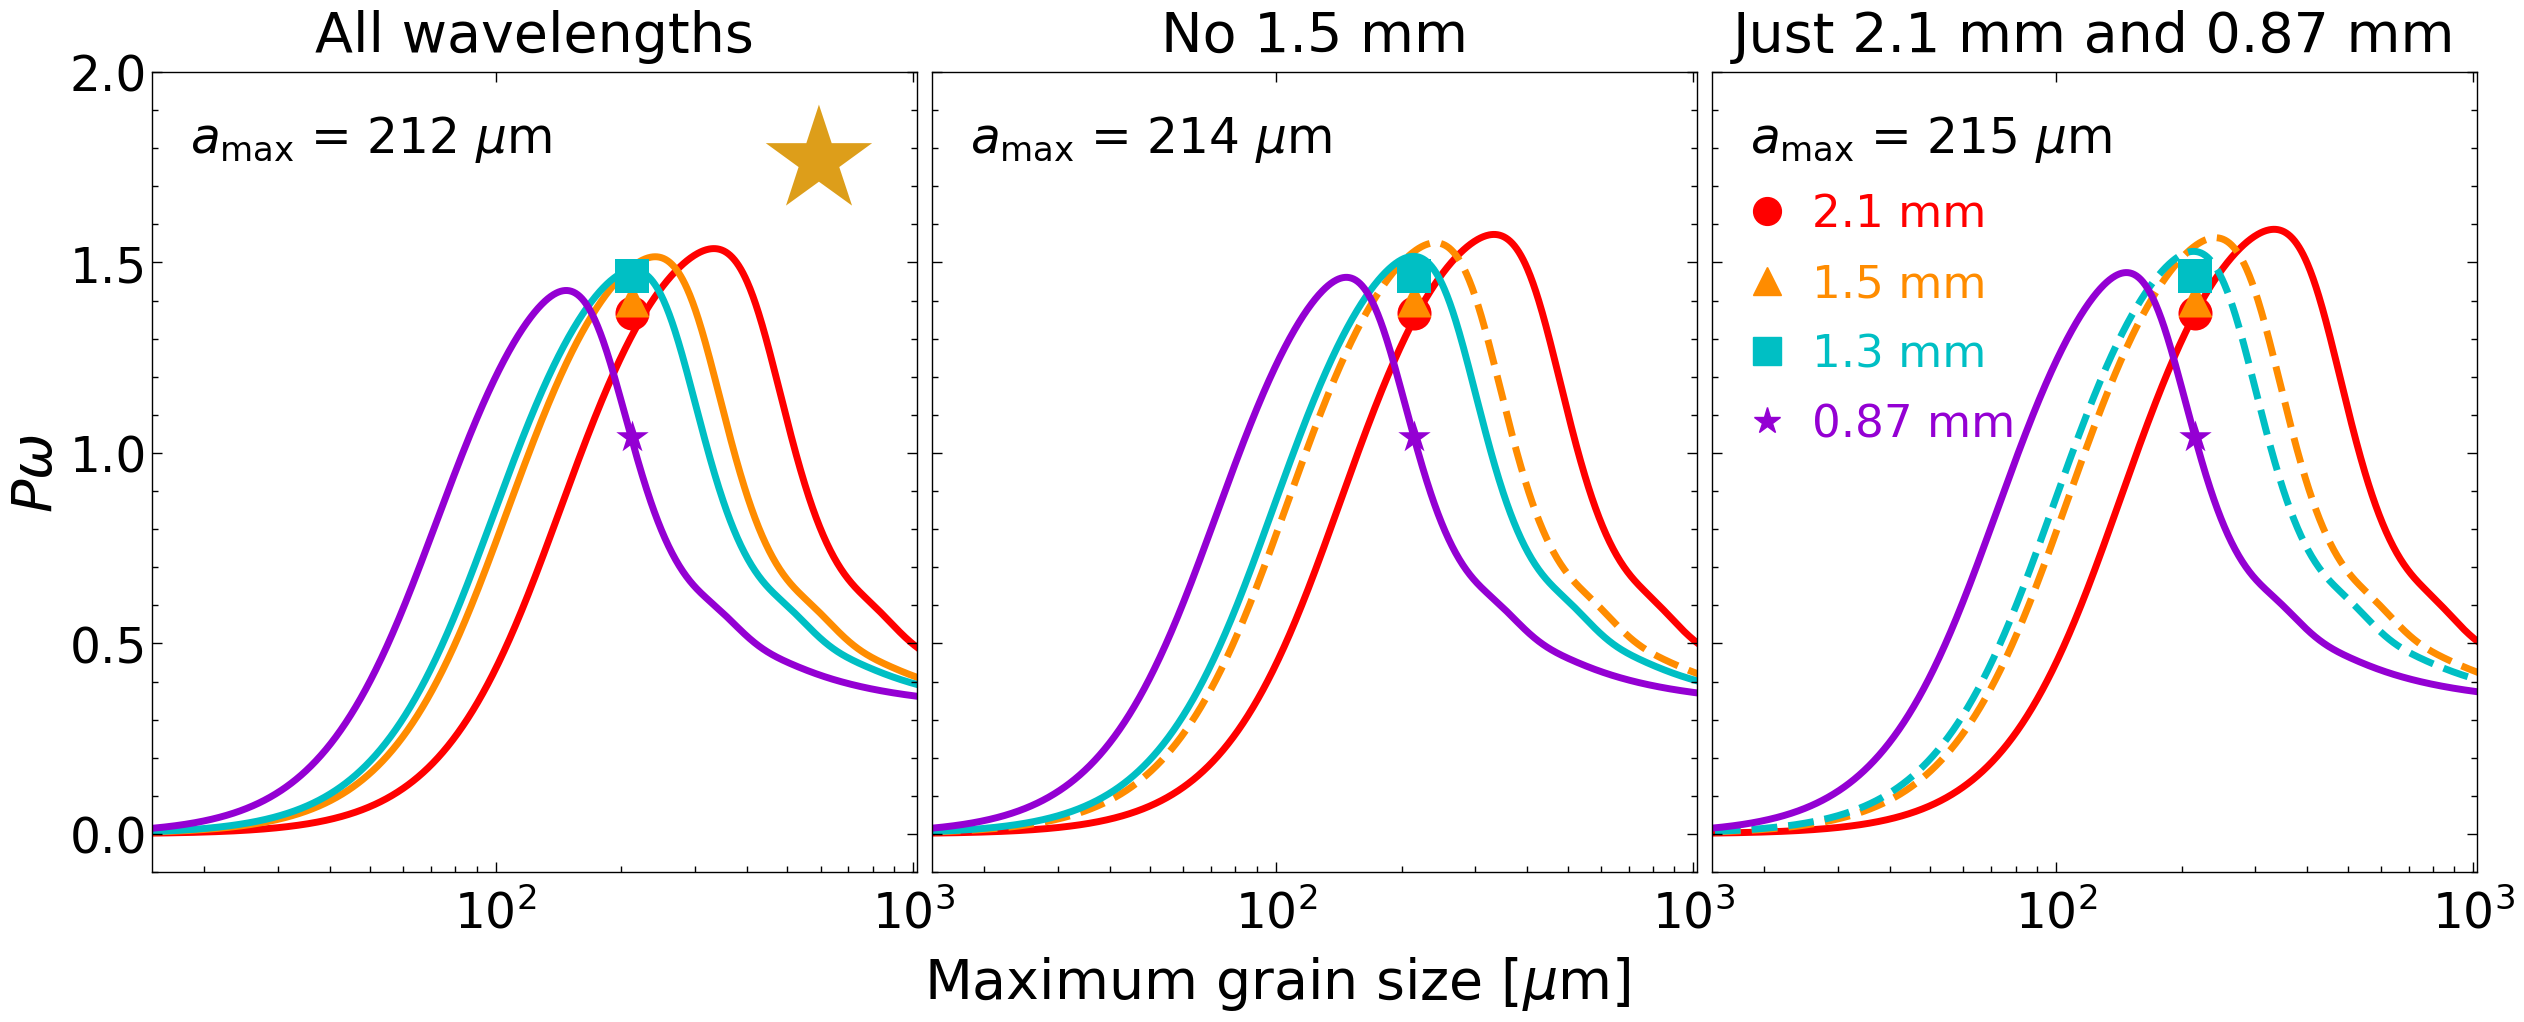

In [21]:


fig, ax = scale_factor_plot_for_writeup_glitterin(BandsIndex,                  
                                        bands_labels, 
                                        results_array_3,
                                        bands_included_in_fit_3,             
                                        df_POLF,  
                                        albedo = 'w',
                                        plot_sf = False,
                                        plot_chi_sq = False, 
                                        BandLegend_bbox_to_anchor=(0.45, 0.90),
                                        legend_loc = 2,
                                        fig_x = 25, fig_y = 10,
                                        #xmin = 10, 
                                        titles = ['All wavelengths', 'No 1.5 mm',  'Just 2.1 mm and 0.87 mm'],
                                        x_axis_pad = 12.5,
                                                 )


ax[2].text(
    0.85, 0.88,
    r'$\star$',
    transform=ax[0].transAxes,
    fontsize=200,
    color= '#dd9e1aff',
    ha='center',
    va='center'
)


plt.savefig(writeup_image_folder_path + '/glitterin/' + "DustModelPlot_GlitterinGrid_only3.pdf", 
            dpi=300, 
            bbox_inches='tight')

i = 0 and P_times_omega[:, j] * sf max is 1.5503672414862377
i = 0 and P_times_omega[:, j] * sf max is 1.5229326550630933
i = 0 and P_times_omega[:, j] * sf max is 1.4783682640506721
i = 0 and P_times_omega[:, j] * sf max is 1.409313515210186
i = 1 and P_times_omega[:, j] * sf max is 1.5854108404875629
i = 1 and P_times_omega[:, j] * sf max is 1.5573561386365034
i = 1 and P_times_omega[:, j] * sf max is 1.5117844400606946
i = 1 and P_times_omega[:, j] * sf max is 1.441168817858886
i = 2 and P_times_omega[:, j] * sf max is 1.6023052482280593
i = 2 and P_times_omega[:, j] * sf max is 1.5739515906993886
i = 2 and P_times_omega[:, j] * sf max is 1.5278942723476172
i = 2 and P_times_omega[:, j] * sf max is 1.4565261580574111


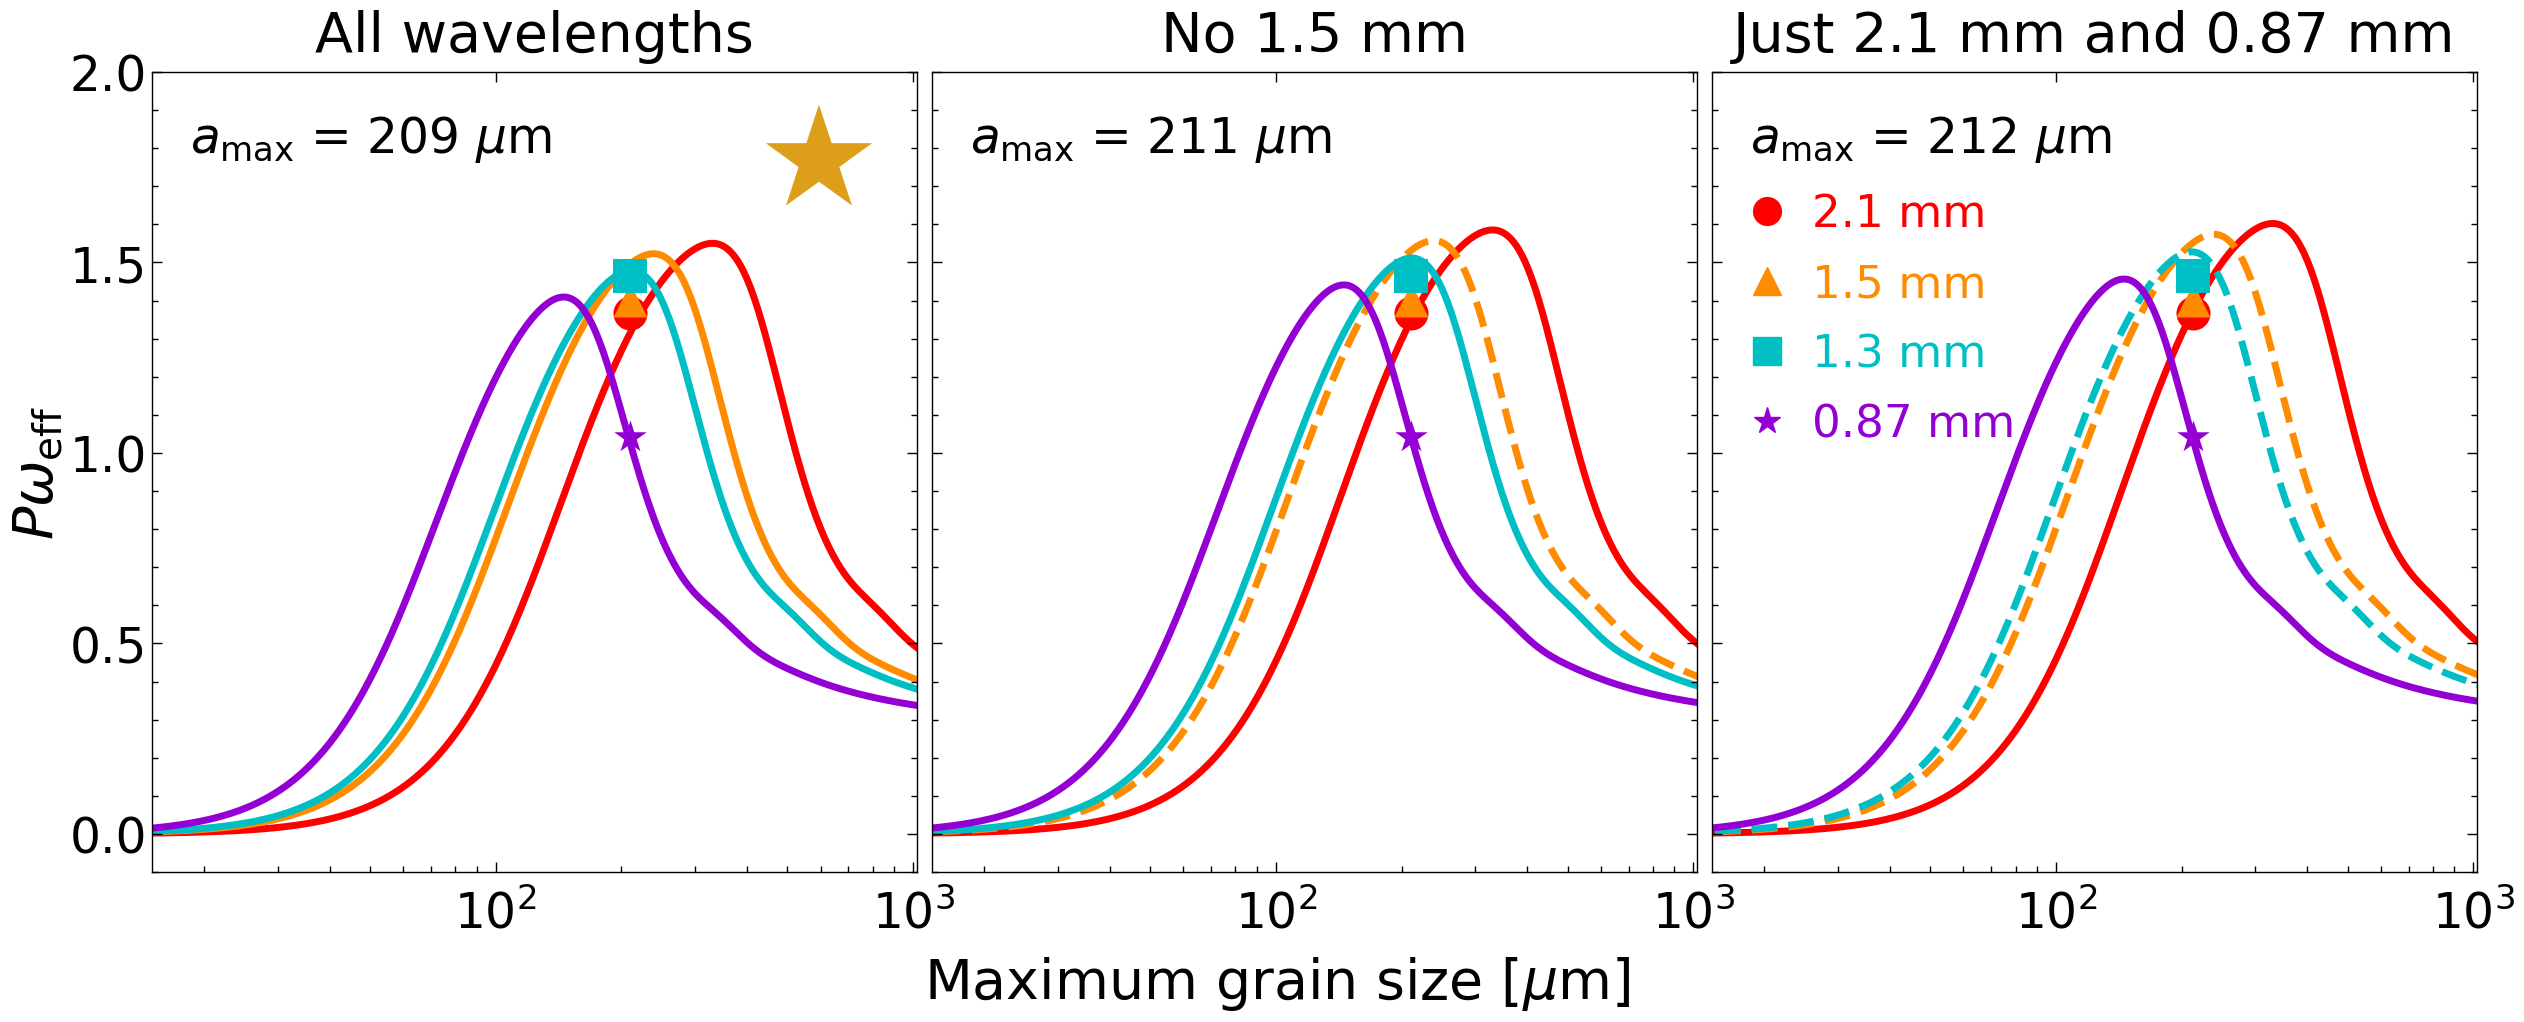

In [22]:


fig, ax = scale_factor_plot_for_writeup_glitterin(BandsIndex,                  
                                        bands_labels, 
                                        results_array_w_eff_3,
                                        bands_included_in_fit_3,             
                                        df_POLF,   
                                        albedo = 'w_eff',
                                        plot_sf = False,
                                        plot_chi_sq = False, 
                                        BandLegend_bbox_to_anchor=(0.45, 0.90),
                                        legend_loc = 2,
                                        fig_x = 25, fig_y = 10,
                                        #xmin = 10, 
                                        titles = ['All wavelengths', 'No 1.5 mm',  'Just 2.1 mm and 0.87 mm'],
                                        x_axis_pad = 12.5,
                                                 )


ax[2].text(
    0.85, 0.88,
    r'$\star$',
    transform=ax[0].transAxes,
    fontsize=200,
    color= '#dd9e1aff',
    ha='center',
    va='center'
)


plt.savefig(writeup_image_folder_path + '/glitterin/' + "DustModelPlot_GlitterinGrid_only3_omega_eff.pdf", 
            dpi=300, 
            bbox_inches='tight')

In [23]:


# fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_all, results, sf_results_all, df_POLF,
#                                             chi_sq_precision=4,
#                                             for_slideshow = True,
#                                              xmin = xmin, xmax = xmax,
#                                             plot_sf = 1,
#                                             BandLegend_bbox_to_anchor = (0.3, 1.0),)




# plt.savefig(image_folder_path + '/Writeup/glitterin/' + "BestGlitterin.png", 
#             dpi=1000, 
#             bbox_inches='tight')

In [24]:
# fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_all, results, sf_results_all, df_POLF,
#                                             chi_sq_precision=4,
#                                             for_slideshow = True,
#                                              xmin = xmin, xmax = xmax,
#                                             plot_sf = 1,
#                                             BandLegend_bbox_to_anchor = (0.3, 1.0),)

# fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_wo5, results, sf_results_wo5, df_POLF,
#                                             chi_sq_precision=4)




# fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_wo6, results, sf_results_wo6, df_POLF)




# fig, ax = plot_scale_factor_resultsGlitterin(BandsIndex, BandsInFit_just47, results, sf_results_just47, df_POLF)

